In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import math
import os

In [2]:
from dask.distributed import Client
client = Client()
client

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.02/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 38529 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/38529/status,
Dashboard: /proxy/38529/status,Workers: 7
Total threads: 7,Total memory: 256.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40053,Workers: 0
Dashboard: /proxy/38529/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42927,Total threads: 1
Dashboard: /proxy/44497/status,Memory: 36.57 GiB
Nanny: tcp://127.0.0.1:33611,


### Staggered grid (shared across all experiments)

In [3]:
# mom6 needs staggered grid even in cartesian coord.
Lx = 1000e3  # m
Ly = 400e3   # m
dx = 1000
dy = 1000
nx = int(Lx/dx)
ny = int(Ly/dy)
nxp = nx + 1  # For u-points
nyp = ny + 1  # For v-points

# Cell centers
xh = np.linspace(dx/2, Lx - dx/2, nx)
yh = np.linspace(dy/2, Ly - dy/2, ny)

# Cell corners/edges (q-points)
xq = np.linspace(0, Lx, nxp)  # u is at eastern faces
yq = np.linspace(0, Ly, nyp)  # v is at northern faces

# Create meshgrids for computation
Xh, Yh   = np.meshgrid(xh, yh)    # eta/h grid (ny, nx)
Xq, Yh_u = np.meshgrid(xq, yh)    # u grid     (ny, nxp)
Xh_v, Yq = np.meshgrid(xh, yq)    # v grid     (nyp, nx)

In [4]:
f = -1e-5
g = 9.81

### Velocity profile — computed once, shared across all experiments

All experiments (test41–test51) use the **same** tanh velocity profile and the **same**
random noise realisation (fixed seed for reproducibility).

In [5]:
U    = 0.30   # m/s
Ljet = 20e3   # m
y0   = Ly / 2  # m

yprime_h = (Yh   - y0) / Ljet   # for eta
yprime_u = (Yh_u - y0) / Ljet   # for u
yprime_v = (Yq   - y0) / Ljet   # for v

# VELOCITY FIELDS (tanh profile) ON STAGGERED GRID
# u at (ny, nx+1) — eastern faces
u_clean = U * np.tanh(yprime_u)

# v at (ny+1, nx) — northern faces
v = np.zeros((nyp, nx))

# Add small decaying noise to u (fixed seed so every run is identical)
rng          = np.random.default_rng(seed=42)
random_noise = rng.standard_normal(u_clean.shape)
decay_factor = 1.0 / np.cosh(yprime_u)**2   # sech²
noise        = 1e-3 * decay_factor * random_noise
u            = u_clean + noise

# FREE SURFACE HEIGHT (geostrophically balanced)
eta_t  = -(f * U * Ljet / g) * np.log(np.cosh(yprime_h))
eta_t -= eta_t.mean()

# 3-D arrays required for NetCDF output
zl   = 1
z    = np.array([-250.0])
h_3d = eta_t[np.newaxis, :, :]   # (1, ny,  nx )
u_3d = u    [np.newaxis, :, :]   # (1, ny,  nxp)
v_3d = v    [np.newaxis, :, :]   # (1, nyp, nx )

print("Velocity and eta fields computed — shared by all experiments.")

Velocity and eta fields computed — shared by all experiments.


### Experiment loop — test126 to test131

There are no half-cells. The slope centre is always a whole grid-cell index:
- **Even widths** → centred on cell **200** (`slope_start = 200 - width/2`)
- **Odd widths**  → centred on cell **201** (`slope_start = 201 - width//2`)

| Experiment | Slope width (cells) | slope_start | slope_end | centre cell |
|------------|---------------------|-------------|-----------|-------------|
| test126     | 5                   | 199         | 204       | 201         |
| test127     | 15                  | 195         | 205       | 200         |
| test128     | 25                  | 194         | 209       | 201         |
| test129     | 35                  | 190         | 210       | 200         |
| test130     | 45                  | 189         | 214       | 201         |
| test131     | 55                  | 185         | 215       | 200         |

Shelf depth = 100 m · Deep basin depth = 500 m

In [6]:
# ── Configuration ──────────────────────────────────────────────────────────────
base_dir      = "/scratch/nm03/ae7501/mom6_input_directories/idealized"
shallow_depth = 100.0    # m  (shelf)
deep_depth    = 500.0    # m  (basin)

# Slope centring rule (no half-cells):
#   Even slope widths  → centred on cell 200
#   Odd  slope widths  → centred on cell 201
def slope_indices(slope_width):
    if slope_width % 2 == 0:
        start = 200 - slope_width // 2
    else:
        start = 201 - slope_width // 2
    return start, start + slope_width   # (inclusive, exclusive)

# Experiment list: (experiment_number, slope_width_in_grid_cells)
# test41 → width 5, test42 → width 10, …, test51 → width 55
experiments = [(126 + i, 5 + i * 10) for i in range(6)]

# ── Loop over experiments ──────────────────────────────────────────────────────
for exp_num, slope_width in experiments:

    exp_name  = f"test{exp_num}"
    input_dir = os.path.join(base_dir, exp_name, "INPUT")

    # 1. Create output directory if it does not already exist
    os.makedirs(input_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f" {exp_name}  |  slope width = {slope_width} grid cells")

    # 2. Build bathymetry profile — slope centred on a whole grid-cell index
    slope_start, slope_end = slope_indices(slope_width)
    centre_cell = slope_start + slope_width // 2

    depth_profile_y = np.zeros(ny)
    depth_profile_y[:slope_start]            = shallow_depth
    depth_profile_y[slope_start:slope_end]   = np.linspace(
        shallow_depth, deep_depth, slope_width)
    depth_profile_y[slope_end:]              = deep_depth

    # Tile into 2-D array (ny, nx)
    depth_2d = np.tile(depth_profile_y[:, np.newaxis], (1, nx))

    print(f" slope indices: [{slope_start}, {slope_end})  centre cell = {centre_cell}")

    # 3. Write init_vel.nc ──────────────────────────────────────────────────────
    vel_path = os.path.join(input_dir, "init_vel.nc")
    nc_vel = Dataset(vel_path, "w", format="NETCDF4")

    nc_vel.createDimension("zl", zl)
    nc_vel.createDimension("yh", ny)
    nc_vel.createDimension("xh", nx)
    nc_vel.createDimension("yq", nyp)
    nc_vel.createDimension("xq", nxp)

    zl_v = nc_vel.createVariable("zl", "f4", ("zl",))
    zl_v[:] = z ; zl_v.axis = "Z" ; zl_v.long_name = "depth to layer"

    xh_v = nc_vel.createVariable("xh", "f4", ("xh",))
    xh_v[:] = xh ; xh_v.axis = "X"
    xh_v.long_name = "h-point longitude" ; xh_v.units = "meters"

    yh_v = nc_vel.createVariable("yh", "f4", ("yh",))
    yh_v[:] = yh ; yh_v.axis = "Y"
    yh_v.long_name = "h-point latitude" ; yh_v.units = "meters"

    xq_v = nc_vel.createVariable("xq", "f4", ("xq",))
    xq_v[:] = xq ; xq_v.axis = "X"
    xq_v.long_name = "q-point longitude" ; xq_v.units = "meters"

    yq_v = nc_vel.createVariable("yq", "f4", ("yq",))
    yq_v[:] = yq ; yq_v.axis = "Y"
    yq_v.long_name = "q-point latitude" ; yq_v.units = "meters"

    u_var = nc_vel.createVariable("u", "f4", ("zl", "yh", "xq"))
    u_var[:] = u_3d
    u_var.units = "m s-1"
    u_var.long_name = "Eastward velocity"
    u_var.standard_name = "eastward_sea_water_velocity"

    v_var = nc_vel.createVariable("v", "f4", ("zl", "yq", "xh"))
    v_var[:] = v_3d
    v_var.units = "m s-1"
    v_var.long_name = "Northward velocity"
    v_var.standard_name = "northward_sea_water_velocity"

    nc_vel.regrid_method = "bilinear"
    nc_vel.close()
    print(f" Written: {vel_path}")

    # 4. Write init_eta.nc ─────────────────────────────────────────────────────
    eta_path = os.path.join(input_dir, "init_eta.nc")
    nc_h = Dataset(eta_path, "w", format="NETCDF4")

    nc_h.createDimension("yh", ny)
    nc_h.createDimension("xh", nx)

    xh_v2 = nc_h.createVariable("xh", "f4", ("xh",))
    xh_v2[:] = xh ; xh_v2.axis = "X"
    xh_v2.long_name = "h-point longitude" ; xh_v2.units = "meters"

    yh_v2 = nc_h.createVariable("yh", "f4", ("yh",))
    yh_v2[:] = yh ; yh_v2.axis = "Y"
    yh_v2.long_name = "h-point latitude" ; yh_v2.units = "meters"

    h_var = nc_h.createVariable("eta_t", "f4", ("yh", "xh"))
    h_var[:] = h_3d
    h_var.units = "m"
    h_var.long_name = "Free surface height anomaly"
    h_var.standard_name = "sea_floor_depth_below_sea_surface"

    nc_h.close()
    print(f" Written: {eta_path}")

    # 5. Write ocean_topog.nc ──────────────────────────────────────────────────
    topo_path = os.path.join(input_dir, "ocean_topog.nc")
    nc_d = Dataset(topo_path, "w", format="NETCDF4")

    nc_d.createDimension("yh", ny)
    nc_d.createDimension("xh", nx)

    xh_d = nc_d.createVariable("xh", "f4", ("xh",))
    xh_d[:] = xh
    xh_d.long_name = "t-cell center x-location" ; xh_d.units = "meters"

    yh_d = nc_d.createVariable("yh", "f4", ("yh",))
    yh_d[:] = yh
    yh_d.long_name = "t-cell center y-location" ; yh_d.units = "meters"

    depth_var = nc_d.createVariable("depth", "f4", ("yh", "xh"))
    depth_var[:] = depth_2d
    depth_var.units = "m"
    depth_var.long_name = "ocean bottom depth"
    depth_var.standard_name = "sea_floor_depth_below_geoid"

    nc_d.close()
    print(f" Written: {topo_path}")

print(f"\n{'='*60}")
print("All 11 experiments written successfully (test41–test51).")
print(f"{'='*60}")



 test126  |  slope width = 5 grid cells
 slope indices: [199, 204)  centre cell = 201
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test126/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test126/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test126/INPUT/ocean_topog.nc

 test127  |  slope width = 15 grid cells
 slope indices: [194, 209)  centre cell = 201
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test127/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test127/INPUT/init_eta.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test127/INPUT/ocean_topog.nc

 test128  |  slope width = 25 grid cells
 slope indices: [189, 214)  centre cell = 201
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test128/INPUT/init_vel.nc
 Written: /scratch/nm03/ae7501/mom6_input_directories/idealized/test128/INPUT/init_eta.nc
 Written: /

### bathymetry profiles for all experiments

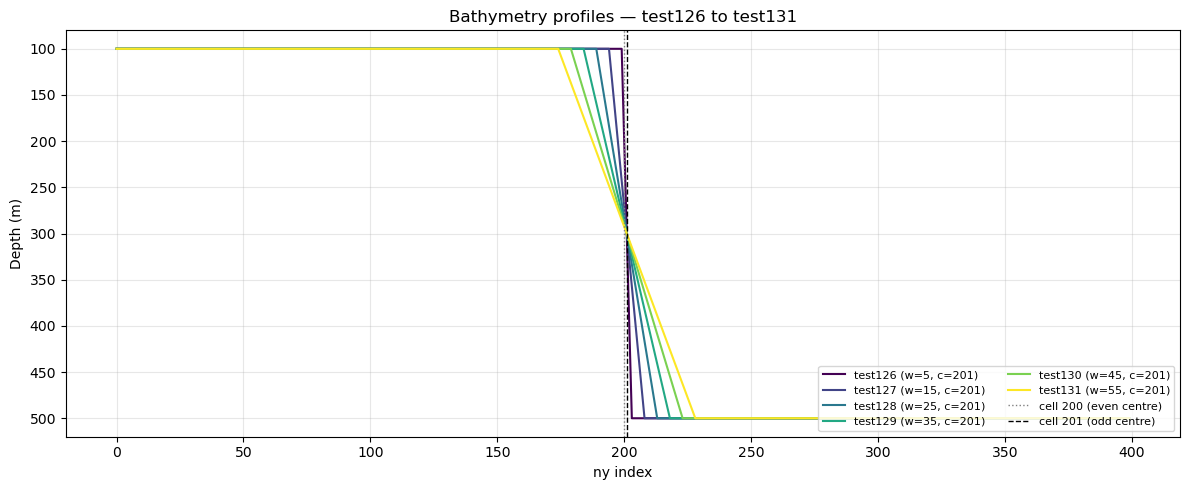

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
colors  = plt.cm.viridis(np.linspace(0, 1, len(experiments)))

for i, (exp_num, slope_width) in enumerate(experiments):
    slope_start, slope_end = slope_indices(slope_width)
    centre_cell = slope_start + slope_width // 2

    profile = np.zeros(ny)
    profile[:slope_start]            = shallow_depth
    profile[slope_start:slope_end]   = np.linspace(shallow_depth, deep_depth, slope_width)
    profile[slope_end:]              = deep_depth

    ax.plot(np.arange(ny), profile,
            color=colors[i], label=f"test{exp_num} (w={slope_width}, c={centre_cell})")

ax.axvline(200, color='gray', linestyle=':', linewidth=1.0, label='cell 200 (even centre)')
ax.axvline(201, color='k',    linestyle='--', linewidth=1.0, label='cell 201 (odd centre)')
ax.set_xlabel("ny index")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()
ax.set_title("Bathymetry profiles — test126 to test131")
ax.legend(loc="lower right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
